# Credit Risk Analysis

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Suppress non-critical warnings for cleaner output

### Load & Explore Data

In [2]:
# Loading raw dataset
df = pd.read_csv('credit_risk_dataset.csv')

In [3]:
# Quick visual check to understand column structure and data types
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
# Confirming dataset dimensions before any transformations
df.shape

(32581, 12)

In [6]:
# Identifying column datatypes and non-null counts across all features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
# Statistical summary to spot outliers — person_age max=144, emp_length max=123 flagged
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
# Null audit: loan_int_rate has 3,116 nulls, person_emp_length has 895 nulls
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [10]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

### Data Cleaning

In [14]:
# Inspecting unique values in categorical columns to validate data quality
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
loan_grade: ['D' 'B' 'C' 'A' 'E' 'F' 'G']
cb_person_default_on_file: ['Y' 'N']


In [15]:
# Filling 3,116 nulls with median — preferred over mean for skewed interest rate distribution
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

# Filling 895 nulls with median — employment length is right-skewed, median is safer
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

In [16]:
# Removing impossible ages above 80 — age 144 is clearly a data entry error
df = df[df['person_age'] <= 80]
# Removing unrealistic employment lengths — 123 years is impossible
df = df[df['person_emp_length'] <= 60]

In [17]:
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [18]:
# Confirming row count after outlier removal — expect ~32,572 rows
print("\nAfter cleaning:", df.shape)


After cleaning: (32572, 12)


In [20]:
print(df['person_age'].max())
print(df['person_emp_length'].max())

80
41.0


#### Feature Engineering

In [21]:
# Categorize borrowers into risk tiers based on loan grade
def assign_risk_tier(grade):
    if grade in ['A', 'B']:
        return 'Low Risk'
    elif grade in ['C', 'D']:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['risk_tier'] = df['loan_grade'].apply(assign_risk_tier)
print(df['risk_tier'].value_counts())

risk_tier
Low Risk       21223
Medium Risk    10080
High Risk       1269
Name: count, dtype: int64


In [22]:
# Bin income into bands for segmentation analysis
def income_band(income):
    if income < 30000:
        return 'Low'
    elif income <= 70000:
        return 'Medium'
    else:
        return 'High'

df['income_band'] = df['person_income'].apply(income_band)
print(df['income_band'].value_counts())

income_band
Medium    18390
High      10514
Low        3668
Name: count, dtype: int64


In [23]:
# Flag high-burden borrowers (loan is >30% of income)
df['high_loan_burden'] = df['loan_percent_income'].apply(
    lambda x: 'High Burden' if x > 0.3 else 'Normal Burden'
)
print(df['high_loan_burden'].value_counts())

high_loan_burden
Normal Burden    28739
High Burden       3833
Name: count, dtype: int64


In [24]:
# Saving cleaned dataset for SQL import and Power BI use
df.to_csv('credit_risk_cleaned.csv', index=False)
print("Updated with new features!")
print(df[['risk_tier', 'income_band', 'high_loan_burden']].head())

Updated with new features!
     risk_tier income_band high_loan_burden
1     Low Risk         Low    Normal Burden
2  Medium Risk         Low      High Burden
3  Medium Risk      Medium      High Burden
4  Medium Risk      Medium      High Burden
5     Low Risk         Low    Normal Burden


#### Exploratory Data Analysis (EDA)

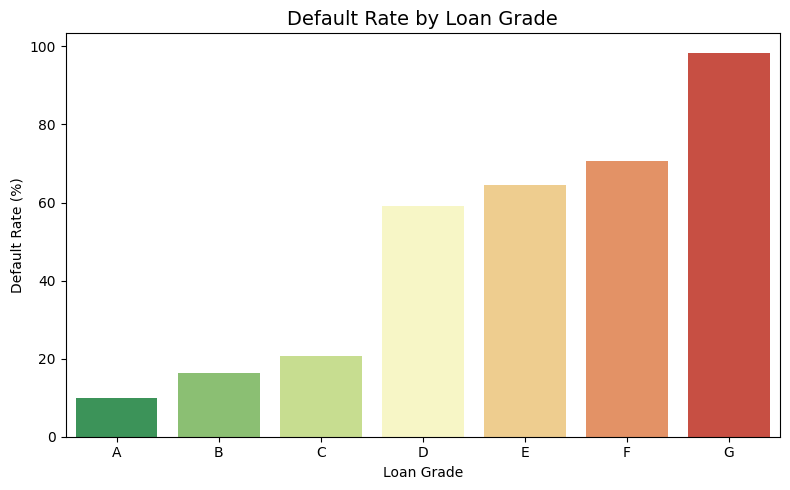

In [25]:
# chart 1
# Calculating average default rate per grade — reveals A(10%) to G(98%) risk escalation
grade_default = df.groupby('loan_grade')['loan_status'].mean() * 100

plt.figure(figsize=(8,5))
sns.barplot(x=grade_default.index, y=grade_default.values, palette='RdYlGn_r')
plt.title('Default Rate by Loan Grade', fontsize=14)
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.savefig('chart1_default_by_grade.png')
plt.show()
# Green to red gradient reinforces visual risk escalation across grades

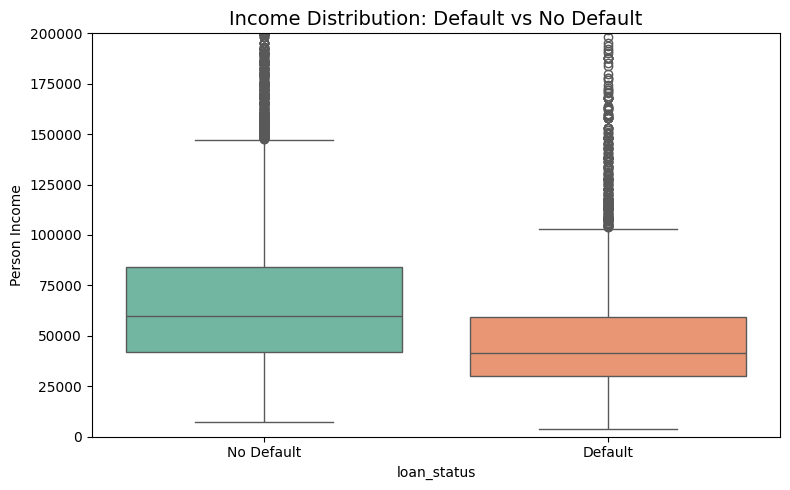

In [47]:
# chart 2
# Box plot reveals defaulters have significantly lower median income than non-defaulters
plt.figure(figsize=(8,5))
sns.boxplot(x='loan_status', y='person_income', data=df, palette='Set2')
plt.title('Income Distribution: Default vs No Default', fontsize=14)
plt.xticks([0, 1], ['No Default', 'Default'])
plt.ylabel('Person Income')
plt.ylim(0, 200000)
plt.tight_layout()
plt.savefig('chart2_income_vs_default.png')
plt.show()

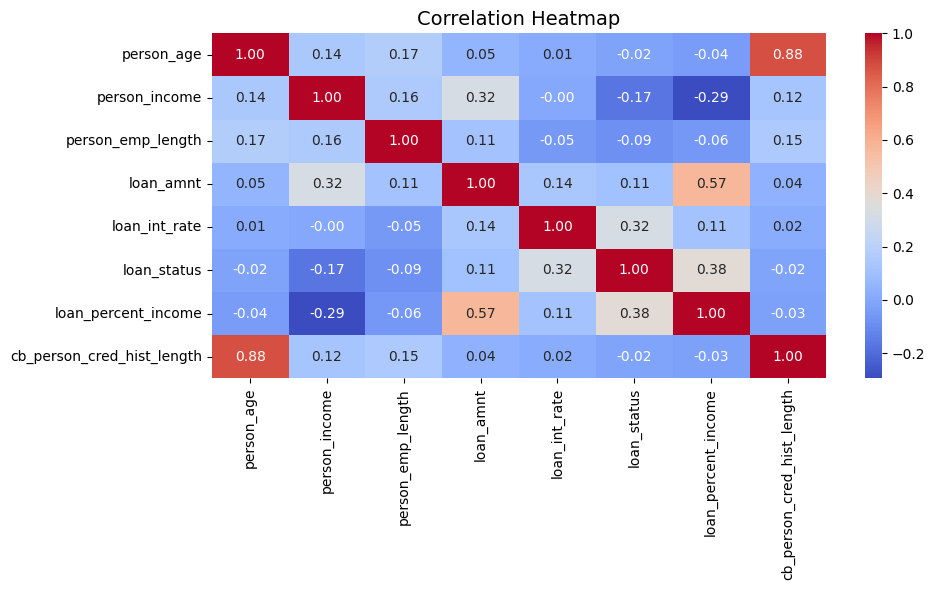

In [27]:
# chart 3
# loan_percent_income (0.38) and loan_int_rate (0.32) show strongest correlation with default
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('chart3_correlation_heatmap.png')
plt.show()

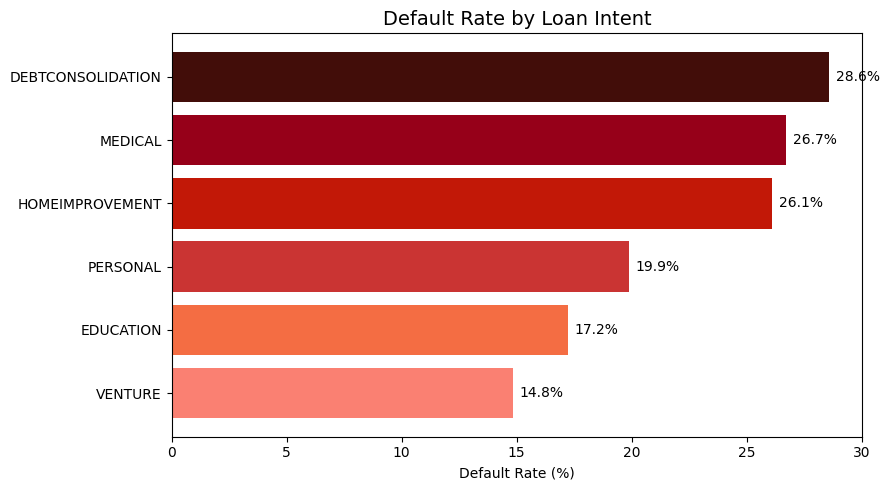

In [64]:
# chart 4
# Debt consolidation at 29% is highest — borrowers already financially stressed at application
intent_default = df.groupby('loan_intent')['loan_status'].mean().sort_values() * 100

plt.figure(figsize=(9,5))
bars = plt.barh(intent_default.index, intent_default.values, color='steelblue')
for bar, val in zip(bars, intent_default.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
colors = ['#fa8072', '#f46d43' , '#ca3433', '#c21807', '#960019','#420d09']
bars = plt.barh(intent_default.index, intent_default.values, color=colors)
plt.title('Default Rate by Loan Intent', fontsize=14)
plt.xlabel('Default Rate (%)')
plt.tight_layout()
plt.savefig('chart4_intent_horizontal.png')
plt.show()
# Sorted horizontal bars with % labels make ranking immediately readable

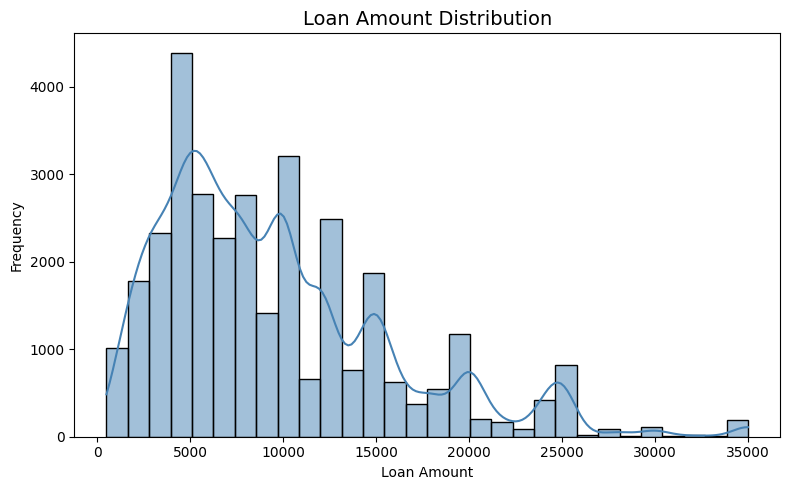

In [29]:
# Chart 5
# Right-skewed distribution — majority of loans cluster between $5K–$15K
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=30, kde=True, color='steelblue')
plt.title('Loan Amount Distribution', fontsize=14)
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart5_loan_amount_dist.png')
plt.show()

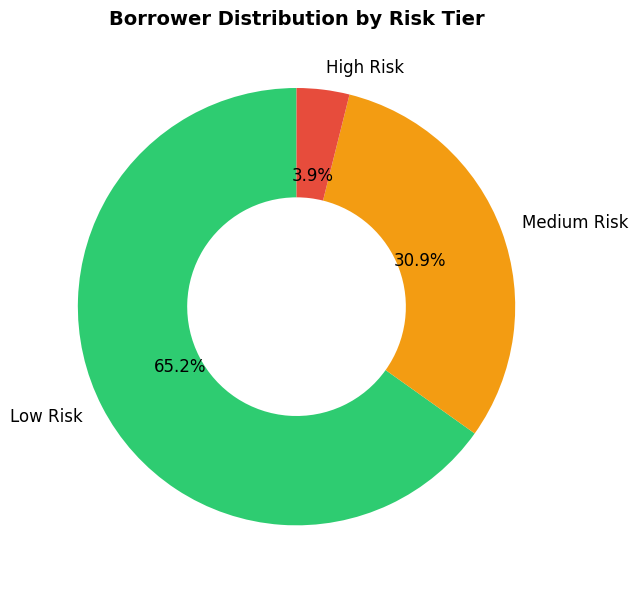

In [43]:
# chart 6
# 65% low risk but 3.9% high risk segment disproportionately drives total defaults
tier_counts = df['risk_tier'].value_counts().reindex(['Low Risk', 'Medium Risk', 'High Risk']) # Reindexing to enforce Low > Medium > High display order
fig, ax = plt.subplots(figsize=(8,6))

wedges, texts, autotexts = ax.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#f39c12', '#e74c3c'],
    startangle=90,
    wedgeprops=dict(width=0.5),  
    textprops={'fontsize': 12}
)

ax.set_title('Borrower Distribution by Risk Tier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_donut_risk_tier.png')
plt.show()

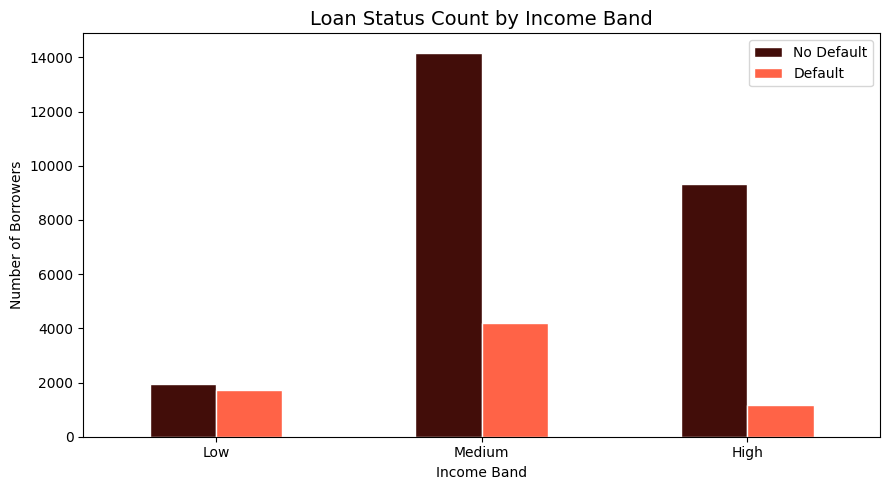

In [51]:
# chart 7
# Low income band shows near 50/50 default split — highest vulnerability segment
income_group = df.groupby(['income_band', 'loan_status']).size().unstack()
income_group = income_group.reindex(['Low', 'Medium', 'High'])

income_group.plot(kind='bar', figsize=(9,5), color=['#420D09', 'tomato'],
                  edgecolor='white')
plt.title('Loan Status Count by Income Band', fontsize=14)
plt.xlabel('Income Band')
plt.ylabel('Number of Borrowers')
plt.xticks(rotation=0)
plt.legend(['No Default', 'Default'])
plt.tight_layout()
plt.savefig('chart7_income_band_grouped.png')
plt.show()

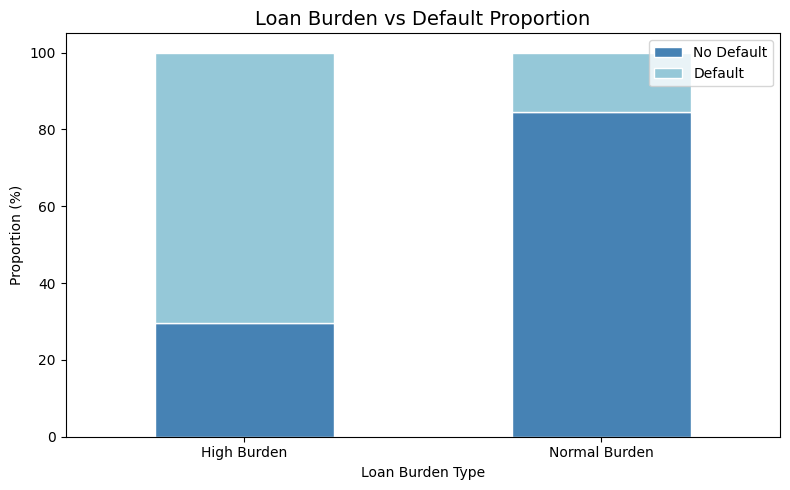

In [50]:
# chart 8
# High burden borrowers default at 70% vs 16% — strongest single risk flag in the dataset
burden_group = df.groupby(['high_loan_burden', 'loan_status']).size().unstack()
burden_pct = burden_group.div(burden_group.sum(axis=1), axis=0) * 100 # Converting raw counts to proportions for fair comparison across burden groups

burden_pct.plot(kind='bar', stacked=True, figsize=(8,5),
                color=['steelblue', '#95C8D8'], edgecolor='white')
plt.title('Loan Burden vs Default Proportion', fontsize=14)
plt.xlabel('Loan Burden Type')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=0)
plt.legend(['No Default', 'Default'], loc='upper right')
plt.tight_layout()
plt.savefig('chart8_loan_burden_stacked.png')
plt.show()